## Step (1) EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("telecommunications_churn.csv")
df

,account_length,voice_mail_plan,voice_mail_messages,day_mins,evening_mins,night_mins,international_mins,customer_service_calls,international_plan,day_calls,day_charge,evening_calls,evening_charge,night_calls,night_charge,international_calls,international_charge,total_charge,churn
0,128,1,25,265.1,197.4,244.7,10.0,1,0,110,45.07,99,16.78,91,11.01,3,2.70,75.56,0
1,107,1,26,161.6,195.5,254.4,13.7,1,0,123,27.47,103,16.62,103,11.45,3,3.70,59.24,0
2,137,0,0,243.4,121.2,162.6,12.2,0,0,114,41.38,110,10.30,104,7.32,5,3.29,62.29,0
3,84,0,0,299.4,61.9,196.9,6.6,2,1,71,50.90,88,5.26,89,8.86,7,1.78,66.80,0
4,75,0,0,166.7,148.3,186.9,10.1,3,1,113,28.34,122,12.61,121,8.41,3,2.73,52.09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,1,36,156.2,215.5,279.1,9.9,2,0,77,26.55,126,18.32,83,12.56,6,2.67,60.10,0
3329,68,0,0,231.1,153.4,191.3,9.6,3,0,57,39.29,55,13.04,123,8.61,4,2.59,63.53,0
3330,28,0,0,180.8,288.8,191.9,14.1,2,0,109,30.74,58,24.55,91,8.64,6,3.81,67.74,0
3331,184,0,0,213.8,159.6,139.2,5.0,2,1,105,36.35,84,13.57,137,6.26,10,1.35,57.53,0


In [3]:
print("The size of data:", df.size)
print("The number of rows and columns:", df.shape)
print("The Data type:", df.dtypes)

The size of data: 63327
The number of rows and columns: (3333, 19)
The Data type: account_length              int64
voice_mail_plan             int64
voice_mail_messages         int64
day_mins                  float64
evening_mins              float64
night_mins                float64
international_mins        float64
customer_service_calls      int64
international_plan          int64
day_calls                   int64
day_charge                float64
evening_calls               int64
evening_charge            float64
night_calls                 int64
night_charge              float64
international_calls         int64
international_charge      float64
total_charge              float64
churn                       int64
dtype: object


In [4]:
df.isnull().sum()

account_length            0
voice_mail_plan           0
voice_mail_messages       0
day_mins                  0
evening_mins              0
night_mins                0
international_mins        0
customer_service_calls    0
international_plan        0
day_calls                 0
day_charge                0
evening_calls             0
evening_charge            0
night_calls               0
night_charge              0
international_calls       0
international_charge      0
total_charge              0
churn                     0
dtype: int64

In [5]:
# Count of churn vs non-churn
chrun_counts = df['churn'].value_counts()
print(chrun_counts)

churn
0    2850
1     483
Name: count, dtype: int64


In [6]:
# Percentage distribution
churn_percentage = df['churn'].value_counts(normalize=True) * 100
print(churn_percentage)

churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64


In [7]:
summary=df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
account_length,3333.0,101.064806,39.822106,1.00,74.00,101.00,127.00,243.00
voice_mail_plan,3333.0,0.276628,0.447398,0.00,0.00,0.00,1.00,1.00
voice_mail_messages,3333.0,8.099010,13.688365,0.00,0.00,0.00,20.00,51.00
day_mins,3333.0,179.775098,54.467389,0.00,143.70,179.40,216.40,350.80
evening_mins,3333.0,200.980348,50.713844,0.00,166.60,201.40,235.30,363.70
night_mins,3333.0,200.872037,50.573847,23.20,167.00,201.20,235.30,395.00
international_mins,3333.0,10.237294,2.791840,0.00,8.50,10.30,12.10,20.00
customer_service_calls,3333.0,1.562856,1.315491,0.00,1.00,1.00,2.00,9.00
international_plan,3333.0,0.096910,0.295879,0.00,0.00,0.00,0.00,1.00
day_calls,3333.0,100.435644,20.069084,0.00,87.00,101.00,114.00,165.00


In [8]:
X = df.drop('churn', axis=1)
y = df['churn']

In [9]:
X['voice_mail_plan'] = X['voice_mail_plan'].astype('category')
X['international_plan'] = X['international_plan'].astype('category')

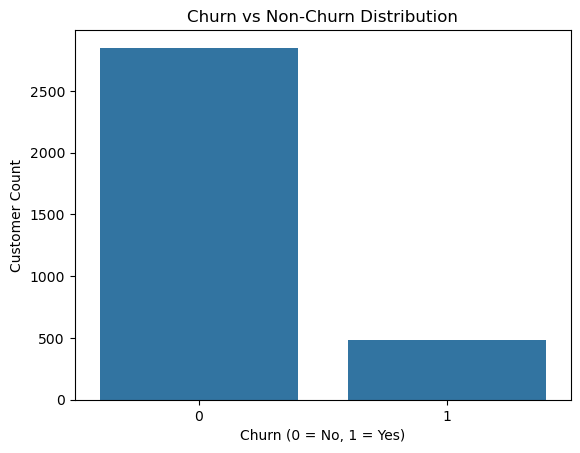

In [10]:
# Churn VS Non-Churn

sns.countplot(x='churn', data=df)
plt.title("Churn vs Non-Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

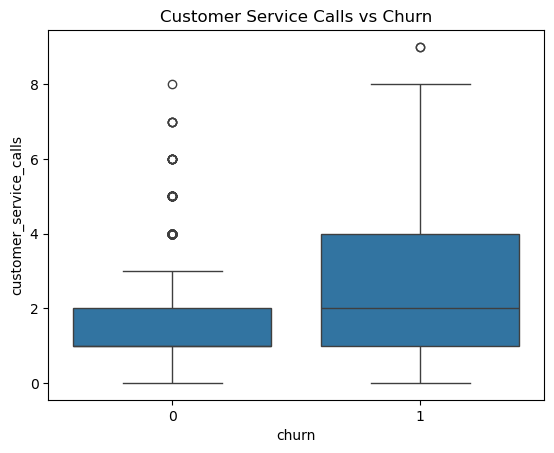

In [11]:
# Customer Service Calls vs Churn

sns.boxplot(x='churn', y='customer_service_calls', data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

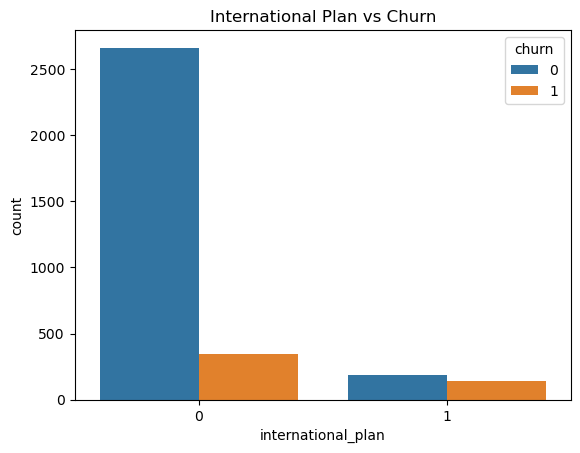

In [12]:
# International Plan vs Churn

sns.countplot(x='international_plan', hue='churn', data=df)
plt.title("International Plan vs Churn")
plt.show()

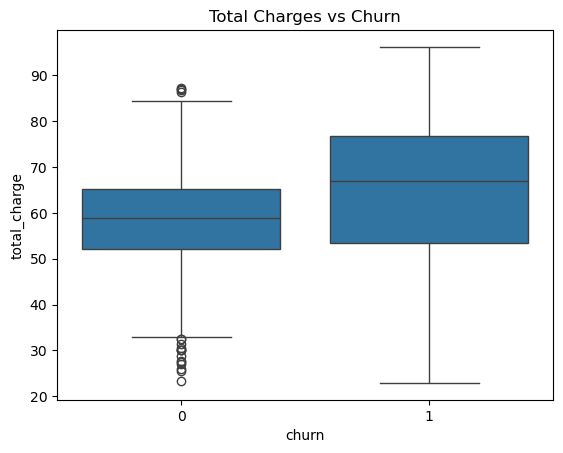

In [13]:
# Total Charges vs Churn

sns.boxplot(x='churn', y='total_charge', data=df)
plt.title("Total Charges vs Churn")
plt.show()

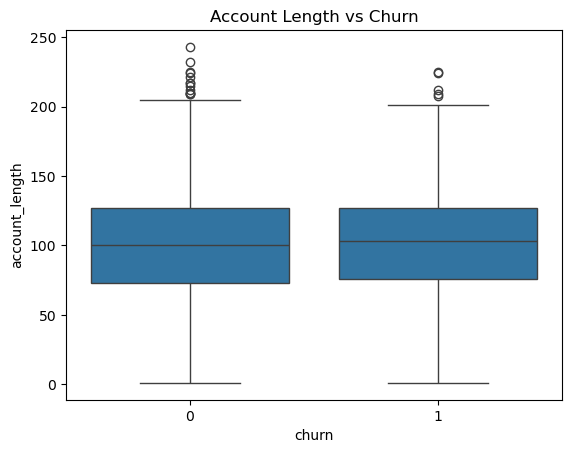

In [14]:
# Account Length vs Churn

sns.boxplot(x='churn', y='account_length', data=df)
plt.title("Account Length vs Churn")
plt.show()

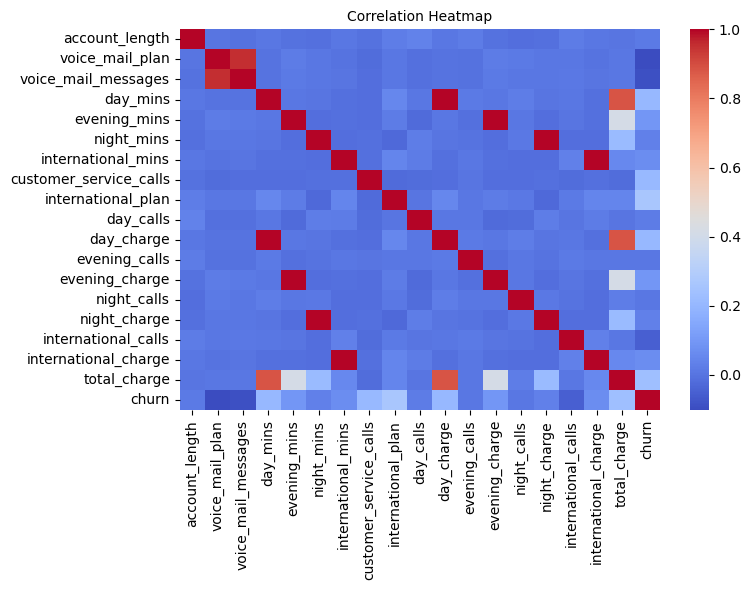

In [5]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, cbar=True)
plt.title("Correlation Heatmap", fontsize=10)
plt.tight_layout()
plt.show()

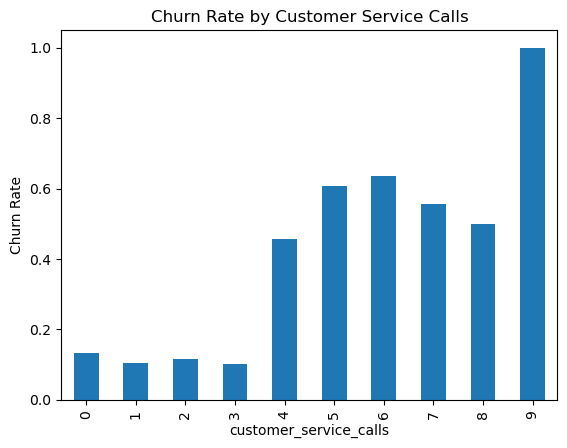

In [16]:
# Churn Rate by Customer Service Calls

churn_rate = df.groupby('customer_service_calls')['churn'].mean()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Customer Service Calls")
plt.ylabel("Churn Rate")
plt.show()

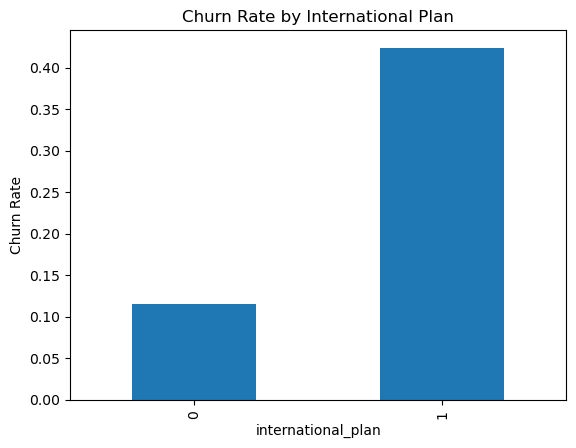

In [22]:
df.groupby('international_plan')['churn'].mean().plot(kind='bar')
plt.title("Churn Rate by International Plan")
plt.ylabel("Churn Rate")
plt.show()

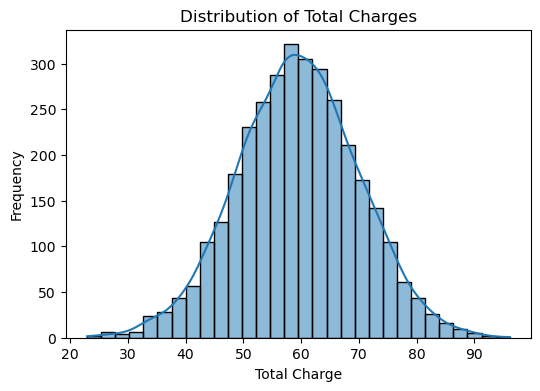

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['total_charge'], bins=30, kde=True)
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charge")
plt.ylabel("Frequency")
plt.show()

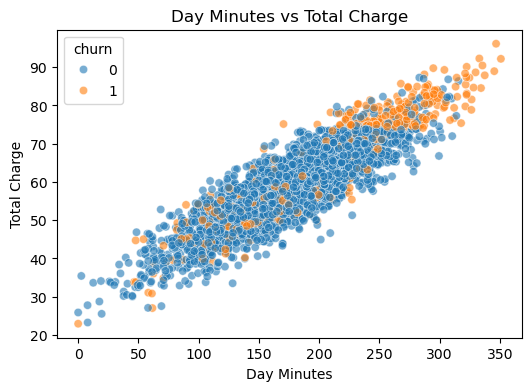

In [20]:
# Scatter Plot
# Day Minutes vs Total Charge

plt.figure(figsize=(6,4))
sns.scatterplot( x='day_mins', y='total_charge',hue='churn', data = df, alpha=0.6)
plt.title('Day Minutes vs Total Charge')
plt.xlabel("Day Minutes")
plt.ylabel("Total Charge")
plt.show()                 

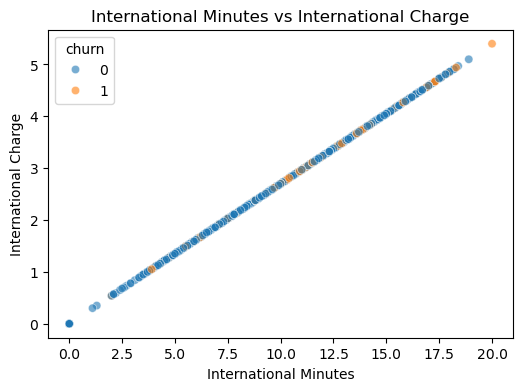

In [21]:
# International Minutes vs International Charge

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='international_mins',
    y='international_charge',
    hue='churn',
    data=df,
    alpha=0.6
)
plt.title("International Minutes vs International Charge")
plt.xlabel("International Minutes")
plt.ylabel("International Charge")
plt.show()